In [1]:
import numpy
import pandas

import matplotlib.pyplot as pyplot
import seaborn

In [2]:
atlas = pandas.read_csv("atlas_inundaciones.csv")

atlas.head()

,id,geo_point_2d,intensidad,alcaldia,area_m2,perime_m,intens_num,int2
0,35.0,"19.2422518066,-99.0731823535",Bajo,Xochimilco,973904.029201,6805.448256,26 a 49,2
1,56.0,"19.2236128042,-99.1083418839",Muy Bajo,Xochimilco,795548.364401,4693.752691,0 a 25,1
2,32.0,"19.3809650541,-99.1373113251",Muy Alto,Benito Juárez,168263.324089,1712.409605,100,5
3,45.0,"19.2603567,-99.0628861422",Muy Alto,Xochimilco,267499.368896,2488.603256,100,5
4,31.0,"19.3905750675,-99.144452701",Muy Alto,Benito Juárez,202062.408324,2113.713857,100,5


In [3]:
grouped = atlas.groupby("alcaldia")

In [14]:
grouped["area_m2"].nlargest(3)

alcaldia                    
Azcapotzalco            824     2.043973e+06
                        4321    2.043973e+06
                        743     1.928335e+06
Benito Juárez           2640    4.868854e+05
                        3341    4.868854e+05
                        3044    4.614507e+05
Coyoacán                2781    7.251734e+06
                        4897    7.251734e+06
                        153     1.501951e+06
Cuajimalpa de Morelos   1783    3.680818e+07
                        2081    3.680818e+07
                        3836    3.305472e+06
Cuauhtémoc              407     6.214439e+05
                        463     6.214439e+05
                        803     5.006941e+05
Gustavo A. Madero       151     2.980252e+06
                        3575    2.980252e+06
                        923     2.273693e+06
Iztacalco               1996    1.629848e+06
                        3750    1.629848e+06
                        67      9.772363e+05
Iztapalapa              22

In [11]:
grouped["area_m2"].nsmallest(3)

alcaldia                    
Azcapotzalco            2063     48626.666935
                        3225     48626.666935
                        3419     53357.884784
Benito Juárez           2936     96728.747792
                        4256     96728.747792
                        3200    116166.057893
Coyoacán                3299     30972.150333
                        3590     30972.150333
                        2766     35878.339604
Cuajimalpa de Morelos   930      98264.922460
                        4536     98264.922460
                        4767    111144.284821
Cuauhtémoc              2498     23088.140813
                        4822     23088.140813
                        343      25179.326629
Gustavo A. Madero       286      34821.350630
                        1829     34821.350630
                        1828     51325.890420
Iztacalco               1510     46465.356706
                        3951     46465.356706
                        3931     47942.230542
Iztap

In [16]:
area_cuartiles = pandas.qcut(atlas["area_m2"], 4)

area_cuartiles

0       (361328.904, 163864401.434]
1       (361328.904, 163864401.434]
2          (148794.756, 233259.493]
3          (233259.493, 361328.904]
4          (148794.756, 233259.493]
                   ...             
4903       (233259.493, 361328.904]
4904    (361328.904, 163864401.434]
4905       (148794.756, 233259.493]
4906         (5990.911, 148794.756]
4907       (233259.493, 361328.904]
Name: area_m2, Length: 4908, dtype: category
Categories (4, interval[float64, right]): [(5990.911, 148794.756] < (148794.756, 233259.493] < (233259.493, 361328.904] < (361328.904, 163864401.434]]

In [17]:
area_cuartiles.value_counts()

area_m2
(5990.911, 148794.756]         1228
(233259.493, 361328.904]       1228
(148794.756, 233259.493]       1226
(361328.904, 163864401.434]    1226
Name: count, dtype: int64

In [18]:
def reportador1(group):
    return pandas.DataFrame({
        "count": group.count(),
        "min": group.min(),
        "mean": group.mean(),
        "25%": group.quantile(0.25),
        "50%": group.quantile(0.50),
        "75%": group.quantile(0.75),
        "max": group.max(),
    })

In [22]:
groupo2 = atlas[["area_m2", "perime_m"]].groupby(area_cuartiles, observed=False)

groupo2.apply(reportador1)

count            min          mean  \
area_m2                                                                    
(5990.911, 148794.756]      area_m2    1228    5990.912380  9.282628e+04   
                            perime_m   1228     316.065331  1.434447e+03   
(148794.756, 233259.493]    area_m2    1226  148826.484569  1.903542e+05   
                            perime_m   1226    1551.231234  2.126353e+03   
(233259.493, 361328.904]    area_m2    1228  233348.741023  2.867699e+05   
                            perime_m   1228    1903.725402  2.637867e+03   
(361328.904, 163864401.434] area_m2    1226  361378.666619  1.865702e+06   
                            perime_m   1226    2437.137766  5.476686e+03   

                                                25%            50%  \
area_m2                                                              
(5990.911, 148794.756]      area_m2    65444.960601   98491.344619   
                            perime_m    1176.811326    1449.296960   
(148794.756, 233259.493]    area_m2   168944.511166  190434.556288   
                            perime_m    1866.994331    2043.186565   
(233259.493, 361328.904]    area_m2   259821.335859  280250.783942   
                            perime_m    2317.220762    2536.266921   
(361328.904, 163864401.434] area_m2   425144.435288  556546.514640   
                            perime_m    3166.700322    4022.051853   

                                                75%           max  
area_m2                                                            
(5990.911, 148794.756]      area_m2   126010.802268  1.487948e+05  
                            perime_m    1703.135835  3.136049e+03  
(148794.756, 233259.493]    area_m2   211977.456662  2.331702e+05  
                            perime_m    2318.796684  3.815721e+03  
(233259.493, 361328.904]    area_m2   312726.134789  3.613289e+05  
                            perime_m    2856.819207  5.533104e+03  
(361328.904, 163864401.434] area_m2   895262.910859  1.638644e+08  
                            perime_m    5448.395296  1.141957e+05

In [24]:
atlas.groupby("alcaldia").size().sort_values(ascending=False)

alcaldia
Iztapalapa                916
Gustavo A. Madero         612
Tlalpan                   422
Álvaro Obregón            400
Coyoacán                  312
Cuauhtémoc                306
Venustiano Carranza       302
Miguel Hidalgo            262
Xochimilco                252
Tláhuac                   230
Iztacalco                 220
Azcapotzalco              206
Benito Juárez             204
La Magdalena Contreras    106
Milpa Alta                 92
Cuajimalpa de Morelos      66
dtype: int64

In [32]:
atlas.groupby(["alcaldia", "intensidad"]).size().unstack().fillna(0)

intensidad,Alto,Bajo,Medio,Muy Alto,Muy Bajo
alcaldia,,,,,
Azcapotzalco,28.0,0.0,10.0,168.0,0.0
Benito Juárez,30.0,10.0,8.0,134.0,22.0
Coyoacán,22.0,8.0,16.0,198.0,68.0
Cuajimalpa de Morelos,0.0,0.0,0.0,0.0,66.0
Cuauhtémoc,6.0,0.0,2.0,298.0,0.0
Gustavo A. Madero,84.0,24.0,18.0,402.0,84.0
Iztacalco,2.0,0.0,0.0,218.0,0.0
Iztapalapa,76.0,26.0,26.0,640.0,148.0
La Magdalena Contreras,0.0,8.0,0.0,0.0,98.0


In [55]:
reporte0 = atlas.groupby(["alcaldia", "intensidad"]).size().unstack().fillna(0)

reporte0

intensidad,Alto,Bajo,Medio,Muy Alto,Muy Bajo
alcaldia,,,,,
Azcapotzalco,28.0,0.0,10.0,168.0,0.0
Benito Juárez,30.0,10.0,8.0,134.0,22.0
Coyoacán,22.0,8.0,16.0,198.0,68.0
Cuajimalpa de Morelos,0.0,0.0,0.0,0.0,66.0
Cuauhtémoc,6.0,0.0,2.0,298.0,0.0
Gustavo A. Madero,84.0,24.0,18.0,402.0,84.0
Iztacalco,2.0,0.0,0.0,218.0,0.0
Iztapalapa,76.0,26.0,26.0,640.0,148.0
La Magdalena Contreras,0.0,8.0,0.0,0.0,98.0


<Axes: xlabel='alcaldia'>

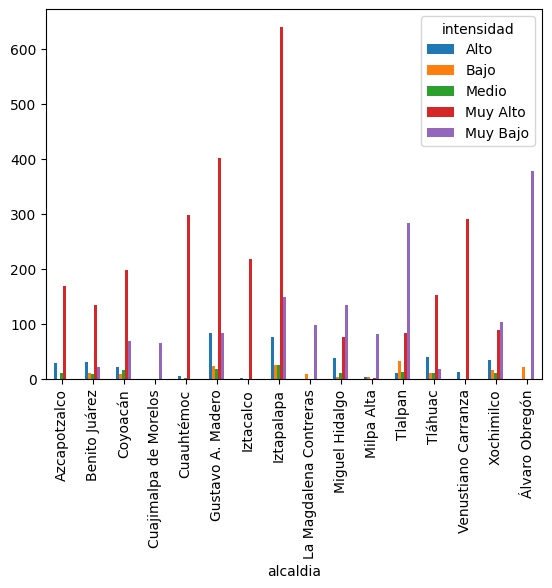

In [58]:
reporte0.plot.bar()

<Axes: xlabel='intensidad', ylabel='alcaldia'>

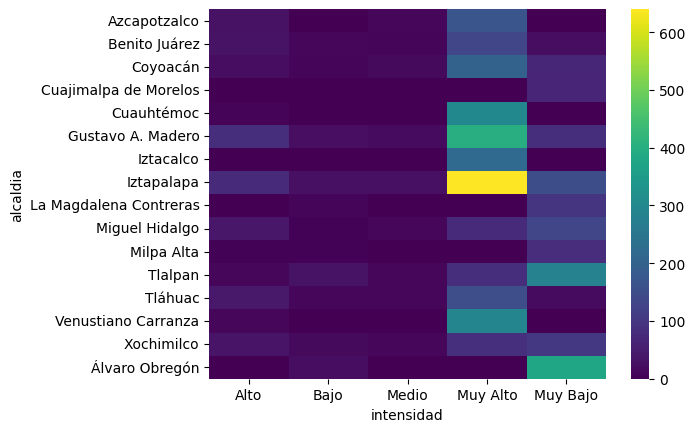

In [57]:
seaborn.heatmap(reporte0, cmap="viridis")

In [49]:
reporte1 = atlas.groupby(["alcaldia", "intensidad"]).size().unstack().fillna(0)

reporte1 = (reporte1 - reporte1.min(axis=0)) / (reporte1.max(axis=0) - reporte1.min(axis=0))

reporte1

intensidad,Alto,Bajo,Medio,Muy Alto,Muy Bajo
alcaldia,,,,,
Azcapotzalco,0.333333,0.0000,0.384615,0.262500,0.000000
Benito Juárez,0.357143,0.3125,0.307692,0.209375,0.058201
Coyoacán,0.261905,0.2500,0.615385,0.309375,0.179894
Cuajimalpa de Morelos,0.000000,0.0000,0.000000,0.000000,0.174603
Cuauhtémoc,0.071429,0.0000,0.076923,0.465625,0.000000
Gustavo A. Madero,1.000000,0.7500,0.692308,0.628125,0.222222
Iztacalco,0.023810,0.0000,0.000000,0.340625,0.000000
Iztapalapa,0.904762,0.8125,1.000000,1.000000,0.391534
La Magdalena Contreras,0.000000,0.2500,0.000000,0.000000,0.259259


<Axes: xlabel='intensidad', ylabel='alcaldia'>

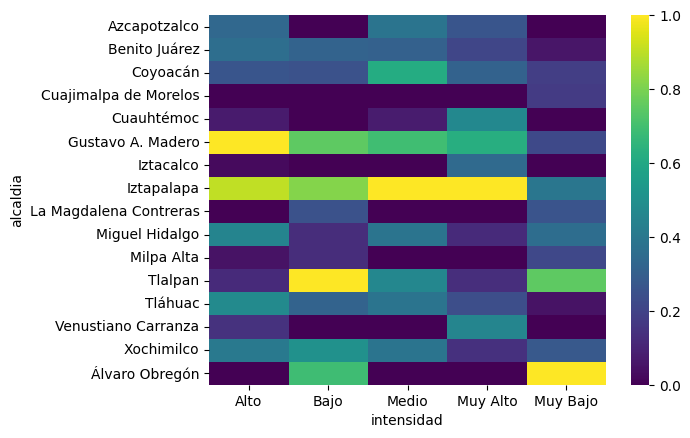

In [50]:
seaborn.heatmap(reporte1, cmap="viridis")

In [53]:
reporte2 = atlas.groupby(["alcaldia", "intensidad"]).size().unstack().fillna(0)

reporte2 = reporte2.divide(reporte2.sum(axis=1), axis=0)

reporte2

intensidad,Alto,Bajo,Medio,Muy Alto,Muy Bajo
alcaldia,,,,,
Azcapotzalco,0.135922,0.000000,0.048544,0.815534,0.000000
Benito Juárez,0.147059,0.049020,0.039216,0.656863,0.107843
Coyoacán,0.070513,0.025641,0.051282,0.634615,0.217949
Cuajimalpa de Morelos,0.000000,0.000000,0.000000,0.000000,1.000000
Cuauhtémoc,0.019608,0.000000,0.006536,0.973856,0.000000
Gustavo A. Madero,0.137255,0.039216,0.029412,0.656863,0.137255
Iztacalco,0.009091,0.000000,0.000000,0.990909,0.000000
Iztapalapa,0.082969,0.028384,0.028384,0.698690,0.161572
La Magdalena Contreras,0.000000,0.075472,0.000000,0.000000,0.924528


<Axes: xlabel='intensidad', ylabel='alcaldia'>

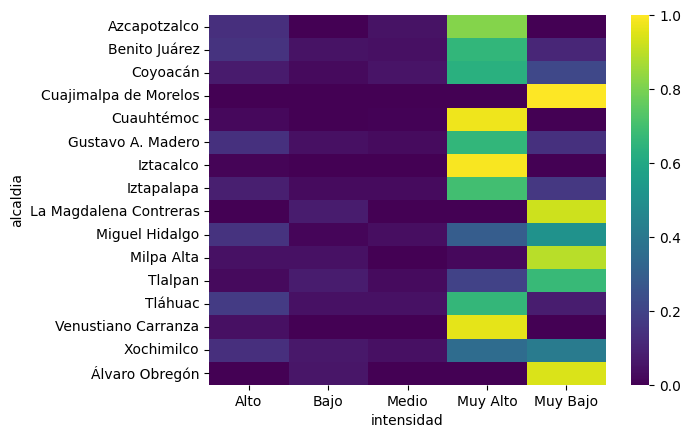

In [54]:
seaborn.heatmap(reporte2, cmap="viridis")

In [68]:
reporteS0 = atlas.groupby(["alcaldia", "intensidad"]).size().reset_index(name="total")

reporteS0["intensidad"] = pandas.Categorical(reporteS0["intensidad"],
                                             categories=["Muy Bajo", "Bajo", "Medio", "Alto", "Muy Alto"],
                                             ordered=True)

reporteS0

,alcaldia,intensidad,total
0,Azcapotzalco,Alto,28
1,Azcapotzalco,Medio,10
2,Azcapotzalco,Muy Alto,168
3,Benito Juárez,Alto,30
4,Benito Juárez,Bajo,10
5,Benito Juárez,Medio,8
6,Benito Juárez,Muy Alto,134
7,Benito Juárez,Muy Bajo,22
8,Coyoacán,Alto,22
9,Coyoacán,Bajo,8


<Axes: xlabel='total', ylabel='alcaldia'>

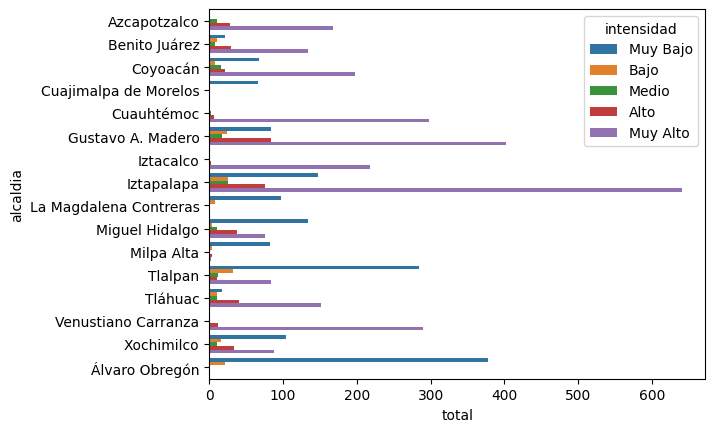

In [78]:
seaborn.barplot(reporteS0, x="total", y="alcaldia", hue="intensidad")

In [86]:
reporteS1 = reporteS0.set_index(["alcaldia", "intensidad"]).unstack().fillna(0)

reporteS1

total                           
intensidad             Muy Bajo  Bajo Medio  Alto Muy Alto
alcaldia                                                  
Azcapotzalco                0.0   0.0  10.0  28.0    168.0
Benito Juárez              22.0  10.0   8.0  30.0    134.0
Coyoacán                   68.0   8.0  16.0  22.0    198.0
Cuajimalpa de Morelos      66.0   0.0   0.0   0.0      0.0
Cuauhtémoc                  0.0   0.0   2.0   6.0    298.0
Gustavo A. Madero          84.0  24.0  18.0  84.0    402.0
Iztacalco                   0.0   0.0   0.0   2.0    218.0
Iztapalapa                148.0  26.0  26.0  76.0    640.0
La Magdalena Contreras     98.0   8.0   0.0   0.0      0.0
Miguel Hidalgo            134.0   4.0  10.0  38.0     76.0
Milpa Alta                 82.0   4.0   0.0   4.0      2.0
Tlalpan                   284.0  32.0  12.0  10.0     84.0
Tláhuac                    18.0  10.0  10.0  40.0    152.0
Venustiano Carranza         0.0   0.0   0.0  12.0    290.0
Xochimilco                104.0  16.0  10.0  34.0     88.0
Álvaro Obregón            378.0  22.0   0.0   0.0      0.0

<Axes: xlabel='None-intensidad', ylabel='alcaldia'>

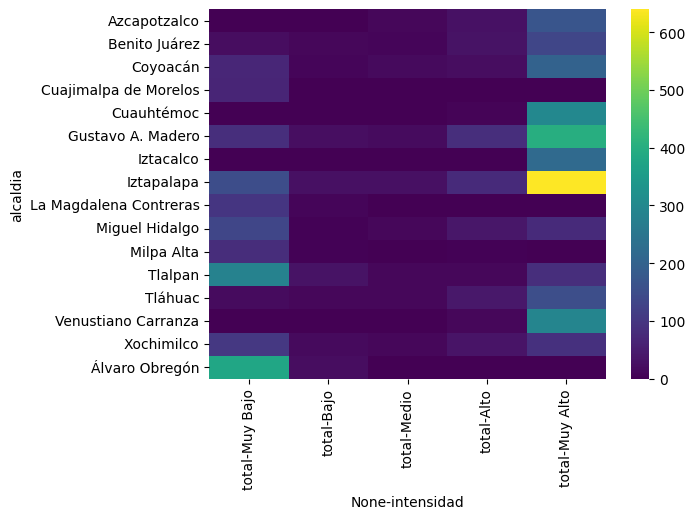

In [88]:
seaborn.heatmap(reporteS1, cmap="viridis")

# Mapas

In [90]:
atlas["geo_point_2d"].str.split(",", expand=True).astype(float)

,0,1
0,19.242252,-99.073182
1,19.223613,-99.108342
2,19.380965,-99.137311
3,19.260357,-99.062886
4,19.390575,-99.144453
...,...,...
4903,19.350470,-99.014514
4904,19.315330,-99.067390
4905,19.310227,-99.068710
4906,19.337578,-99.181183


In [93]:
atlas[["lat", "lon"]] = atlas["geo_point_2d"].str.split(",", expand=True).astype(float)

atlas.head()

,id,geo_point_2d,intensidad,alcaldia,area_m2,perime_m,intens_num,int2,lat,lon
0,35.0,"19.2422518066,-99.0731823535",Bajo,Xochimilco,973904.029201,6805.448256,26 a 49,2,19.242252,-99.073182
1,56.0,"19.2236128042,-99.1083418839",Muy Bajo,Xochimilco,795548.364401,4693.752691,0 a 25,1,19.223613,-99.108342
2,32.0,"19.3809650541,-99.1373113251",Muy Alto,Benito Juárez,168263.324089,1712.409605,100,5,19.380965,-99.137311
3,45.0,"19.2603567,-99.0628861422",Muy Alto,Xochimilco,267499.368896,2488.603256,100,5,19.260357,-99.062886
4,31.0,"19.3905750675,-99.144452701",Muy Alto,Benito Juárez,202062.408324,2113.713857,100,5,19.390575,-99.144453


## Folium

In [96]:
# ! pip install folium
import folium
from folium.plugins import HeatMap

In [99]:
mapa = folium.Map(location=[19.4, -99.1],
                  zoom_start=11,
                  tiles="Cartodb Positron")

zonas = HeatMap(atlas[["lat", "lon"]], 
        radius=7,
        blur=1,
        min_opacity=0.2)

zonas.add_to(mapa)

mapa

Guardar el mapa

In [100]:
mapa.save("mapa_inundaciones.html")

### Crear una paleta de colores

In [106]:
from matplotlib.colors import to_hex

cmap = pyplot.get_cmap("coolwarm", 5)

paleta = [to_hex(cmap(i)) for i in range(5)]

# paleta_intensidad = dict(zip(reporte0.columns, paleta))
paleta_intensidad = {
    "Muy Bajo": paleta[0],
    "Bajo": paleta[1],
    "Medio": paleta[2],
    "Alto": paleta[3],
    "Muy Alto": paleta[4],
}

paleta_intensidad

{'Muy Bajo': '#3b4cc0',
 'Bajo': '#8db0fe',
 'Medio': '#dddddd',
 'Alto': '#f49a7b',
 'Muy Alto': '#b40426'}

In [121]:
mapa = folium.Map(location=[19.4, -99.1],
                  zoom_start=11,
                  tiles="Cartodb Positron") # tiles=OpenStreetMap

for index, lat, lon, intensidad in atlas[["lat", "lon", "intensidad"]].itertuples():
    color = paleta_intensidad[intensidad]
    # print(lat, lon, intensidad, color)
    zona = folium.CircleMarker(location=[lat, lon],
                        radius=3,
                        color=color,
                        fill=True,
                        fill_opacity=0.5)
    zona.add_to(mapa)

mapa

# Matrices SVD

Singular Value Decomposition (Descomposición en Valores Singulares)

## Descomposición de imágenes

Sea $A$ la matriz asociada a una imagen en un solo canal

$$
A = U \Sigma V^T
$$

Y sea $A_k$ la matriz de rango reducido $k$ aproximada a la imagen original

$$
A_k = U_k \Sigma_k V_k^T
$$

### Procesamiento de imágenes con Pillow

In [ ]:
#! pip install pillow
from PIL import Image
import requests


[notice] A new release of pip is available: 25.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
